# GA Optimasi Posisi Object 2D COC Priority

objek: Town hall, defense, storage, army

Aturan:
1. tidak boleh ada yang tumpang tindih

Setiap objek mempunyai posisi:
```
A = (x1, y1)
B = (x2, y2)
C = (x3, y3)
D = (x4, y4)
E = (x5, y5)
```

Individual
[
    (x, y, size),
    (x, y, size),
    ...
]

(x,y) menjadi koordinat pojok kiri bawah objek

### Contoh asli bangunan TH13

|	id	|	name	|	count	|	level	|	size	|	category	|	village	|
|	:------	|	:------	|	:------	|	:------	|	:------	|	:------	|	:------	|
|	1000001	|	Town Hall	|	1	|	13	|	[4, 4]	|	Town Hall	|	home	|
|	1000014	|	Clan Castle	|	1	|	9	|	[3, 3]	|	Army	|	home	|
|	1000031	|	Eagle Artillery	|	1	|	4	|	[4, 4]	|	Defense	|	home	|
|	1000067	|	Scattershot	|	2	|	2	|	[3, 3]	|	Defense	|	home	|
|	1000027	|	Inferno Tower	|	3	|	6	|	[2, 2]	|	Defense	|	home	|
|	1000021	|	X-Bow	|	4	|	5	|	[3, 3]	|	Defense	|	home	|
|	1000012	|	Air Defense	|	4	|	9	|	[3, 3]	|	Defense	|	home	|
|	1000028	|	Air Sweeper	|	2	|	7	|	[2, 2]	|	Defense	|	home	|
|	1000009	|	Archer Tower	|	8	|	15	|	[3, 3]	|	Defense	|	home	|
|	1000000	|	Army Camp	|	4	|	11	|	[4, 4]	|	Army	|	home	|
|	1000006	|	Barracks	|	1	|	15	|	[3, 3]	|	Army	|	home	|
|	1000070	|	Blacksmith	|	1	|	6	|	[3, 3]	|	Army	|	home	|
|	1000032	|	Bomb Tower	|	2	|	6	|	[3, 3]	|	Defense	|	home	|
|	1000015	|	Builder's Hut	|	5	|	1	|	[2, 2]	|	Worker	|	home	|
|	1000008	|	Cannon	|	7	|	19	|	[3, 3]	|	Defense	|	home	|
|	1000026	|	Dark Barracks	|	1	|	10	|	[3, 3]	|	Army	|	home	|
|	1000023	|	Dark Elixir Drill	|	3	|	9	|	[3, 3]	|	Resource	|	home	|
|	1000024	|	Dark Elixir Storage	|	1	|	8	|	[3, 3]	|	Resource	|	home	|
|	1000029	|	Dark Spell Factory	|	1	|	6	|	[3, 3]	|	Army	|	home	|
|	1000002	|	Elixir Collector	|	7	|	15	|	[3, 3]	|	Resource	|	home	|
|	1000003	|	Elixir Storage	|	4	|	14	|	[3, 3]	|	Resource	|	home	|
|	1000004	|	Gold Mine	|	7	|	15	|	[3, 3]	|	Resource	|	home	|
|	1000005	|	Gold Storage	|	4	|	14	|	[3, 3]	|	Resource	|	home	|
|	1000093	|	Helper Hut	|	1	|	1	|	[3, 3]	|	Helper	|	home	|
|	1000071	|	Hero Hall	|	1	|	7	|	[4, 4]	|	Army	|	home	|
|	1000019	|	Hidden Tesla	|	5	|	9	|	[2, 2]	|	Defense	|	home	|
|	1000007	|	Laboratory	|	1	|	11	|	[3, 3]	|	Army	|	home	|
|	1000013	|	Mortar	|	4	|	12	|	[3, 3]	|	Defense	|	home	|
|	1000020	|	Spell Factory	|	1	|	7	|	[3, 3]	|	Army	|	home	|
|	1000010	|	Wall	|	300	|	14	|	[1, 1]	|	Wall	|	home	|
|	1000011	|	Wizard Tower	|	5	|	10	|	[3, 3]	|	Defense	|	home	|
|	1000059	|	Workshop	|	1	|	5	|	[4, 4]	|	Army	|	home	|


## Import

In [54]:
import random
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os
from PIL import Image

## Village

In [55]:
village = {
  "townhall_level": 13,
  "building_count": 393,
  "wall_count": 300,
  "map_size": 44,
  "buildings": [
    {
      "id": 1000001,
      "name": "Town Hall",
      "level": 13,
      "size": [4, 4],
      "category": "Town Hall",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000014,
      "name": "Clan Castle",
      "level": 9,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000031,
      "name": "Eagle Artillery",
      "level": 4,
      "size": [4, 4],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000067,
      "name": "Scattershot",
      "level": 2,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000067,
      "name": "Scattershot",
      "level": 2,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000027,
      "name": "Inferno Tower",
      "level": 6,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000027,
      "name": "Inferno Tower",
      "level": 6,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000027,
      "name": "Inferno Tower",
      "level": 6,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000021,
      "name": "X-Bow",
      "level": 5,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000021,
      "name": "X-Bow",
      "level": 5,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000021,
      "name": "X-Bow",
      "level": 5,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000021,
      "name": "X-Bow",
      "level": 5,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000012,
      "name": "Air Defense",
      "level": 9,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000012,
      "name": "Air Defense",
      "level": 9,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000012,
      "name": "Air Defense",
      "level": 9,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000012,
      "name": "Air Defense",
      "level": 9,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000028,
      "name": "Air Sweeper",
      "level": 7,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000028,
      "name": "Air Sweeper",
      "level": 7,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 8
    },
    {
      "id": 1000000,
      "name": "Army Camp",
      "level": 11,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000000,
      "name": "Army Camp",
      "level": 11,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000000,
      "name": "Army Camp",
      "level": 11,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000000,
      "name": "Army Camp",
      "level": 11,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000006,
      "name": "Barracks",
      "level": 15,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000070,
      "name": "Blacksmith",
      "level": 6,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000032,
      "name": "Bomb Tower",
      "level": 6,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000032,
      "name": "Bomb Tower",
      "level": 6,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000026,
      "name": "Dark Barracks",
      "level": 10,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000023,
      "name": "Dark Elixir Drill",
      "level": 9,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000023,
      "name": "Dark Elixir Drill",
      "level": 9,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000023,
      "name": "Dark Elixir Drill",
      "level": 9,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000024,
      "name": "Dark Elixir Storage",
      "level": 8,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000029,
      "name": "Dark Spell Factory",
      "level": 6,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000003,
      "name": "Elixir Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000003,
      "name": "Elixir Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000003,
      "name": "Elixir Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000003,
      "name": "Elixir Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000005,
      "name": "Gold Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000005,
      "name": "Gold Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000005,
      "name": "Gold Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000005,
      "name": "Gold Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000093,
      "name": "Helper Hut",
      "level": 1,
      "size": [3, 3],
      "category": "Helper",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000071,
      "name": "Hero Hall",
      "level": 7,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000007,
      "name": "Laboratory",
      "level": 11,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000013,
      "name": "Mortar",
      "level": 12,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000013,
      "name": "Mortar",
      "level": 12,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000013,
      "name": "Mortar",
      "level": 12,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000013,
      "name": "Mortar",
      "level": 12,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000020,
      "name": "Spell Factory",
      "level": 7,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000059,
      "name": "Workshop",
      "level": 5,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 1
    }
  ]
}


## Parameter

In [56]:
# =========================================
# 1. Parameter Genetic Algorithm
# =========================================

POPULATION_SIZE = 50
GENERATIONS = 250
MUTATION_RATE = 0.1

GRID_SIZE = 44

OVERLAP_PENALTY = 1000
BOUNDARY_PENALTY = 1000

BUILDINGS = village["buildings"]
NUMBER_OF_OBJECTS = len(BUILDINGS)

# Priority Center
PRIORITY_BUILDING_IDS = [
    1000001,  # Town Hall
    # 1000014,  # Clan Castle
    # 1000067,  # Scattershot
    1000031,  # Eagle Artilery
]
CENTER_RADIUS = 20
CENTER_REWARD_WEIGHT = 100

In [57]:
total_area = sum(
    building["size"][0] * building["size"][1]
    for building in BUILDINGS
)

print("Total building area:", total_area)
print("Map area:", GRID_SIZE * GRID_SIZE)

Total building area: 818
Map area: 1936


## Function

In [58]:
# =========================================
# Center Radius
# =========================================
def random_center_position(size):

    width, height = size

    center_x = GRID_SIZE // 2
    center_y = GRID_SIZE // 2

    min_x = max(
        0,
        center_x - CENTER_RADIUS
    )

    max_x = min(
        GRID_SIZE - width,
        center_x + CENTER_RADIUS
    )

    min_y = max(
        0,
        center_y - CENTER_RADIUS
    )

    max_y = min(
        GRID_SIZE - height,
        center_y + CENTER_RADIUS
    )

    x = random.randint(min_x, max_x)
    y = random.randint(min_y, max_y)

    return (x, y)


# =========================================
# Pengecekan posisi agar tidak overlap ditengah
# =========================================
def position_is_valid(
    position,
    size,
    placed_buildings
):

    for other_position, other_size in placed_buildings:

        if is_overlap(
            position,
            size,
            other_position,
            other_size
        ):
            return False

    return True

def find_valid_position(
    size,
    placed_buildings,
    center=False,
    max_attempts=100
):

    for _ in range(max_attempts):

        if center:
            position = random_center_position(size)

        else:

            width, height = size

            x = random.randint(
                0,
                GRID_SIZE - width
            )

            y = random.randint(
                0,
                GRID_SIZE - height
            )

            position = (x, y)

        if position_is_valid(
            position,
            size,
            placed_buildings
        ):
            return position

    return None

In [59]:
# =========================================
# Fungsi Distance
# =========================================

def distance(point1, point2):

    x1, y1 = point1
    x2, y2 = point2

    return math.sqrt(
        (x2 - x1) ** 2 +
        (y2 - y1) ** 2
    )
    
def building_center(position, size):

    x, y = position
    width, height = size

    return (
        x + width / 2,
        y + height / 2
    )
   
def center_distance(position, size):

    x, y = building_center(
        position,
        size
    )

    center_x = GRID_SIZE / 2
    center_y = GRID_SIZE / 2

    return math.sqrt(
        (x - center_x) ** 2 +
        (y - center_y) ** 2
    )
    
# =========================================
# Fungsi Overlap bangunan 2D
# =========================================
def is_overlap(pos1, size1, pos2, size2):

    x1, y1 = pos1
    w1, h1 = size1

    x2, y2 = pos2
    w2, h2 = size2

    return (
        x1 < x2 + w2 and
        x1 + w1 > x2 and
        y1 < y2 + h2 and
        y1 + h1 > y2
    )


# =========================================
# 2. Fungsi Fitness
# =========================================

def fitness(individual):

    penalty = 0
    center_reward = 0

    # =====================================
    # Boundary
    # =====================================

    for i, building in enumerate(BUILDINGS):

        x, y = individual[i]

        width, height = building["size"]

        if x < 0:
            penalty += BOUNDARY_PENALTY

        if y < 0:
            penalty += BOUNDARY_PENALTY

        if x + width > GRID_SIZE:
            penalty += BOUNDARY_PENALTY

        if y + height > GRID_SIZE:
            penalty += BOUNDARY_PENALTY


    # =====================================
    # Overlap
    # =====================================

    for i in range(NUMBER_OF_OBJECTS):

        for j in range(i + 1, NUMBER_OF_OBJECTS):

            if is_overlap(
                individual[i],
                BUILDINGS[i]["size"],
                individual[j],
                BUILDINGS[j]["size"]
            ):

                penalty += OVERLAP_PENALTY


    # =====================================
    # Center Priority
    # =====================================

    for i, building in enumerate(BUILDINGS):

        if building["id"] in PRIORITY_BUILDING_IDS:

            d = center_distance(
                individual[i],
                building["size"]
            )

            center_reward += (
                CENTER_REWARD_WEIGHT /
                (1 + d)
            )


    return center_reward - penalty


# =========================================
# 3. Membuat individual
# =========================================

def create_individual():

    individual = [None] * NUMBER_OF_OBJECTS

    placed_buildings = []

    # =====================================
    # 1. PRIORITY BUILDINGS
    # =====================================

    priority_indices = []

    for i, building in enumerate(BUILDINGS):

        if building["id"] in PRIORITY_BUILDING_IDS:

            priority_indices.append(i)


    # =====================================
    # 2. PLACE PRIORITY
    # =====================================

    for i in priority_indices:

        building = BUILDINGS[i]
        size = building["size"]

        position = find_valid_position(
            size,
            placed_buildings,
            center=True
        )

        if position is None:
            raise RuntimeError(
                f"Gagal menempatkan "
                f"{building['name']} "
                f"instance {building['instance']}"
            )

        individual[i] = position

        placed_buildings.append(
            (position, size)
        )


    # =====================================
    # 3. PLACE OTHER BUILDINGS
    # =====================================

    for i, building in enumerate(BUILDINGS):

        if individual[i] is not None:
            continue

        size = building["size"]

        position = find_valid_position(
            size,
            placed_buildings,
            center=False
        )

        if position is None:
            raise RuntimeError(
                f"Gagal menempatkan "
                f"{building['name']} "
                f"instance {building['instance']}"
            )

        individual[i] = position

        placed_buildings.append(
            (position, size)
        )


    return individual

In [60]:
# =========================================
# 5. Membuat population
# =========================================

def create_population():
    return [
        create_individual()
        for _ in range(POPULATION_SIZE)
    ]


# =========================================
# 6. Selection
# =========================================

def selection(population):
    population_sorted = sorted(
        population,
        key=fitness,
        reverse=True
    )

    # Ambil 50% terbaik
    return population_sorted[:POPULATION_SIZE // 2]


# =========================================
# 7. Crossover
# =========================================
def crossover(parent1, parent2):

    child1 = []
    child2 = []

    for i in range(NUMBER_OF_OBJECTS):

        if random.random() < 0.5:

            child1.append(parent1[i])
            child2.append(parent2[i])

        else:

            child1.append(parent2[i])
            child2.append(parent1[i])

    return child1, child2

# =========================================
# 8. Mutation
# =========================================
def mutation(individual):

    for i in range(NUMBER_OF_OBJECTS):

        if random.random() < MUTATION_RATE:

            width, height = BUILDINGS[i]["size"]

            max_x = GRID_SIZE - width
            max_y = GRID_SIZE - height

            x = random.randint(0, max_x)
            y = random.randint(0, max_y)

            individual[i] = (x, y)

    return individual




## Run GA

In [ ]:
# =========================================
# 9. Genetic Algorithm
# =========================================

population = create_population()


for generation in range(GENERATIONS):

    # -----------------------------
    # Evaluasi
    # -----------------------------

    best = max(
        population,
        key=fitness
    )

    print(
        f"Generation {generation + 1:02d} | "
        f"Fitness = {fitness(best):.2f} | "
        f"Position = {best}"
    )


    # -----------------------------
    # Selection
    # -----------------------------

    parents = selection(population)


    # -----------------------------
    # Membuat population baru
    # -----------------------------

    new_population = parents.copy()


    while len(new_population) < POPULATION_SIZE:

        parent1, parent2 = random.sample(parents, 2)

        child1, child2 = crossover(
            parent1,
            parent2
        )

        child1 = mutation(child1)
        child2 = mutation(child2)

        new_population.append(child1)

        if len(new_population) < POPULATION_SIZE:
            new_population.append(child2)


    population = new_population


# =========================================
# 10. Hasil akhir
# =========================================

best = max(
    population,
    key=fitness
)

print("\nHasil Akhir")

print("fitness =", fitness(best))
print("best =", best)
print("Generation: ", GENERATIONS)
print("Population: ", POPULATION_SIZE)



Generation 01 | Fitness = 57.67 | Position = [(28, 11), (40, 9), (20, 19), (15, 6), (37, 28), (30, 22), (36, 21), (24, 21), (23, 15), (35, 41), (11, 16), (19, 7), (4, 10), (9, 1), (9, 29), (10, 37), (39, 2), (28, 41), (35, 25), (13, 30), (39, 23), (25, 3), (1, 27), (15, 20), (15, 10), (3, 5), (16, 29), (30, 28), (7, 22), (11, 23), (18, 13), (13, 27), (38, 20), (33, 0), (31, 35), (5, 8), (29, 3), (18, 5), (3, 40), (35, 3), (41, 39), (4, 31), (33, 34), (0, 13), (9, 9), (41, 0), (31, 19), (27, 20), (1, 21), (22, 9), (25, 12), (2, 2), (22, 34), (28, 17), (38, 4), (19, 23), (8, 41), (26, 36), (2, 34), (11, 33), (13, 0), (8, 15), (40, 17), (38, 33), (4, 22), (15, 40), (41, 3), (10, 6), (12, 41), (31, 24), (15, 16), (21, 27), (37, 12), (32, 4), (41, 27), (24, 39), (31, 1), (16, 36), (34, 31), (2, 11), (19, 3), (10, 12), (0, 16), (0, 30), (36, 7), (26, 29), (40, 36), (32, 11), (26, 0), (3, 14), (22, 12), (0, 8), (5, 35)]
Generation 02 | Fitness = 57.67 | Position = [(28, 11), (40, 9), (20, 19)

## Visualisation

In [ ]:
# fitness = 70.40953724607185
# best =  [(20, 21), (14, 37), (34, 12), (22, 11), (18, 4), (37, 36), (39, 24), (15, 6), (16, 20), (9, 10), (16, 31), (32, 40), (34, 5), (24, 31), (3, 37), (39, 27), (23, 37), (5, 22), (29, 5), (18, 7), (24, 18), (12, 16), (40, 20), (28, 22), (27, 36), (5, 14), (10, 1), (3, 1), (11, 19), (18, 10), (19, 36), (0, 10), (29, 16), (34, 21), (23, 27), (15, 42), (41, 35), (29, 39), (29, 8), (28, 29), (41, 8), (18, 25), (41, 31), (8, 37), (15, 14), (36, 16), (20, 30), (10, 24), (2, 23), (27, 33), (37, 30), (35, 27), (23, 6), (7, 40), (32, 16), (22, 14), (0, 4), (22, 41), (6, 9), (30, 25), (11, 39), (19, 41), (34, 36), (39, 39), (3, 26), (29, 1), (35, 8), (27, 41), (33, 2), (17, 0), (29, 10), (11, 29), (25, 27), (6, 6), (26, 7), (9, 6), (29, 19), (33, 31), (1, 8), (28, 25), (1, 36), (40, 17), (14, 8), (2, 19), (15, 17), (36, 0), (8, 20), (23, 3), (8, 27), (40, 5), (7, 17), (3, 30), (10, 32)]

# fitness = 34.83667611505229
# best = [(40, 34), (26, 37), (22, 19), (23, 10), (12, 37), (25, 5), (10, 31), (18, 9), (3, 29), (16, 13), (30, 36), (5, 17), (25, 40), (30, 30), (19, 26), (9, 41), (13, 9), (26, 29), (23, 28), (27, 8), (15, 20), (29, 22), (5, 7), (35, 13), (30, 17), (34, 6), (36, 39), (8, 17), (17, 1), (17, 33), (4, 33), (12, 32), (14, 1), (37, 22), (22, 2), (35, 23), (40, 0), (18, 18), (3, 11), (40, 31), (7, 36), (1, 33), (21, 37), (7, 3), (21, 23), (13, 28), (31, 33), (12, 12), (9, 14), (27, 17), (7, 11), (0, 4), (40, 28), (2, 19), (36, 36), (6, 0), (37, 30), (36, 9), (39, 13), (40, 16), (32, 9), (11, 0), (12, 23), (11, 6), (35, 2), (31, 27), (0, 28), (22, 40), (28, 11), (9, 27), (4, 23), (23, 7), (22, 31), (1, 1), (8, 6), (35, 25), (33, 20), (7, 26), (24, 35), (24, 0), (3, 14), (0, 14), (37, 18), (26, 33), (13, 41), (41, 21), (25, 24), (41, 8), (25, 14), (5, 20), (41, 39), (6, 39), (0, 7)]
# Generation:  100
# Population:  50

# fitness = 58.20995152217657
# best = [(21, 20), (34, 4), (25, 30), (12, 21), (19, 39), (25, 23), (10, 26), (9, 15), (27, 38), (33, 15), (1, 20), (21, 3), (5, 11), (41, 29), (35, 35), (1, 3), (23, 25), (36, 16), (27, 12), (0, 15), (15, 17), (0, 10), (25, 19), (39, 39), (4, 24), (32, 35), (12, 30), (11, 36), (26, 3), (35, 31), (35, 12), (6, 19), (22, 27), (16, 37), (35, 20), (27, 8), (15, 20), (17, 23), (18, 16), (12, 25), (33, 26), (0, 29), (40, 12), (41, 22), (14, 9), (39, 15), (14, 0), (25, 34), (30, 20), (7, 33), (16, 32), (1, 39), (18, 1), (9, 8), (26, 16), (41, 6), (9, 21), (21, 8), (16, 6), (14, 14), (29, 16), (32, 1), (37, 6), (3, 14), (22, 12), (38, 20), (8, 0), (30, 11), (30, 8), (22, 36), (31, 4), (39, 0), (4, 34), (9, 29), (35, 40), (21, 15), (2, 6), (29, 34), (30, 37), (34, 7), (33, 38), (1, 33), (8, 39), (15, 41), (27, 22), (39, 32), (14, 3), (41, 35), (4, 29), (39, 9), (29, 27), (33, 23), (16, 27)]
# Generation:  250
# Population:  50

# fitness = 57.667774013050206
# best = [(28, 11), (40, 9), (20, 19), (15, 6), (37, 28), (30, 22), (36, 21), (24, 21), (23, 15), (35, 41), (11, 16), (19, 7), (4, 10), (9, 1), (9, 29), (10, 37), (39, 2), (28, 41), (35, 25), (13, 30), (39, 23), (25, 3), (1, 27), (15, 20), (15, 10), (3, 5), (16, 29), (30, 28), (7, 22), (11, 23), (18, 13), (13, 27), (38, 20), (33, 0), (31, 35), (5, 8), (29, 3), (18, 5), (3, 40), (35, 3), (41, 39), (4, 31), (33, 34), (0, 13), (9, 9), (41, 0), (31, 19), (27, 20), (1, 21), (22, 9), (25, 12), (2, 2), (22, 34), (28, 17), (38, 4), (19, 23), (8, 41), (26, 36), (2, 34), (11, 33), (13, 0), (8, 15), (40, 17), (38, 33), (4, 22), (15, 40), (41, 3), (10, 6), (12, 41), (31, 24), (15, 16), (21, 27), (37, 12), (32, 4), (41, 27), (24, 39), (31, 1), (16, 36), (34, 31), (2, 11), (19, 3), (10, 12), (0, 16), (0, 30), (36, 7), (26, 29), (40, 36), (32, 11), (26, 0), (3, 14), (22, 12), (0, 8), (5, 35)]
# Generation:  250
# Population:  50


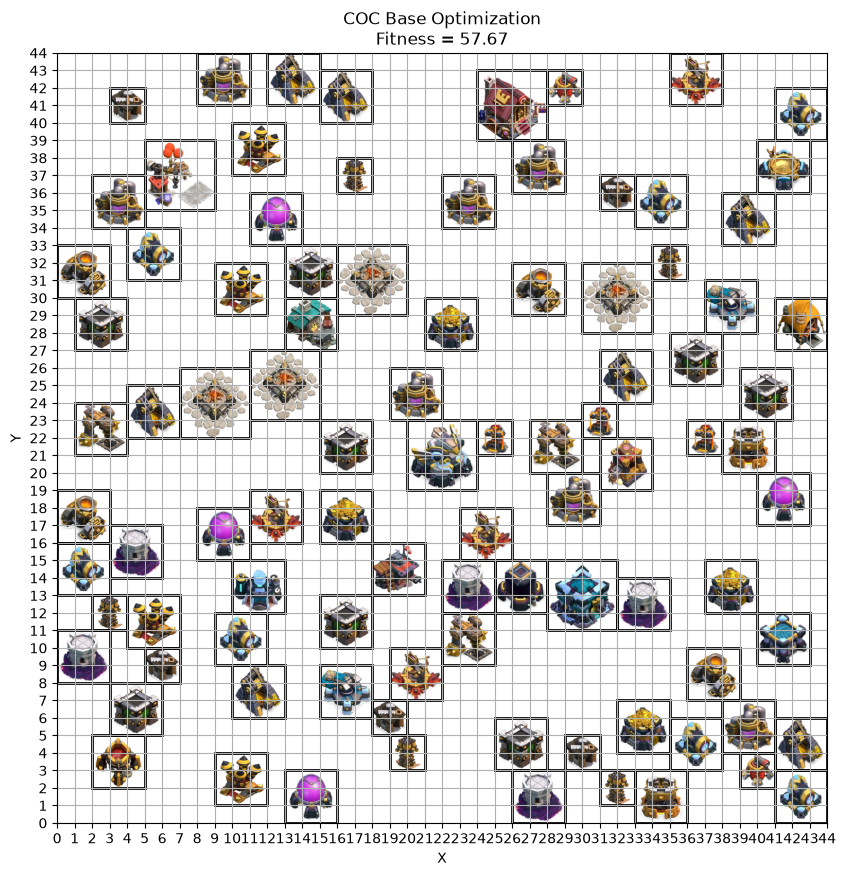

In [63]:

# =========================================
# 11. Visualisasi
# =========================================

fig, ax = plt.subplots(figsize=(10, 10))

for i, (x, y) in enumerate(best):
    bld = BUILDINGS[i]
    width, height = bld["size"]
    name = bld["name"]
    bld_id = bld["id"]
    level = bld["level"]
    
    rectangle = Rectangle(
        (x, y),
        width,
        height,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rectangle)

    folder_name_suffix = name.lower().replace(" ", "_")
    folder_path = f"../../../assets/buildings/{bld_id}_{folder_name_suffix}"

    file_prefix = name.replace(" ", "_")
    img_filename = f"{file_prefix}{level}.webp"
    img_path = os.path.join(folder_path, img_filename)

    try:
        if os.path.exists(img_path):
            img = Image.open(img_path)
            ax.imshow(img, extent=(x, x + width, y, y + height), aspect="auto")
        else:
            print(f"Gambar tidak ditemukan: {img_path}")
    except Exception as e:
        print(f"Gagal memuat gambar {name}: {e}")

    # ax.text(
    #     x + width / 2,
    #     y + height / 2,
    #     # f"{i + 1}",
    #     BUILDINGS[i]["name"],
    #     ha="center",
    #     va="center",
    #     fontsize=6
    # )


# =========================================
# Map
# =========================================

ax.set_xlim(0, GRID_SIZE)
ax.set_ylim(0, GRID_SIZE)

ax.set_xticks(range(GRID_SIZE + 1))
ax.set_yticks(range(GRID_SIZE + 1))

ax.grid(True)

ax.set_aspect("equal")

ax.set_xlabel("X")
ax.set_ylabel("Y")

ax.set_title(
    f"COC Base Optimization\n"
    f"Fitness = {fitness(best):.2f}"
)

plt.show()

## Result